# 03b — Subject-independent classification

This notebook addresses the **unpaired / subject-independent** part of the report.

Main question:

> If the model receives only one recording from a new participant, without being allowed to directly compare that participant's EC and EO recordings, how well can it classify Eyes Closed (EC) vs Eyes Open (EO)?

This is different from the paired analysis in `03a`.

In the paired analysis, the model asks:

> Given the two recordings from the same participant, which one is EC?

In this notebook, the model asks:

> Given one recording from a participant not seen during training, is it EC or EO?

This is a harder problem because it cannot remove each participant's personal baseline alpha level by direct within-person comparison.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# Change this only if the project folder moves.
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")

DATA_DIR = PROJECT_ROOT / "data_processed"
RESULTS_DIR = DATA_DIR / "model_results"
FIGURES_DIR = PROJECT_ROOT / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RECORDING_FEATURES_FILE = DATA_DIR / "recording_features.csv"
FOOOF_FEATURES_FILE = DATA_DIR / "fooof_features.csv"
PAIRED_RESULTS_FILE = RESULTS_DIR / "paired_results.csv"

SUBJECT_RESULTS_FILE = RESULTS_DIR / "subject_independent_results.csv"
SUBJECT_PREDICTIONS_FILE = RESULTS_DIR / "subject_independent_predictions.csv"
SUBJECT_COEFFICIENTS_FILE = RESULTS_DIR / "subject_independent_coefficients.csv"

recording_features = pd.read_csv(RECORDING_FEATURES_FILE)

print("Recording features:", recording_features.shape)
recording_features.head()


Recording features: (1216, 62)


,recording_id,participant_id,pair_id,condition,age,sex,handedness,sfreq,duration_sec,n_eeg_channels,...,ch_PO10_alpha_log,ch_P5_alpha_log,ch_P1_alpha_log,ch_P2_alpha_log,ch_P6_alpha_log,ch_PO7_alpha_log,ch_PO3_alpha_log,ch_POz_alpha_log,ch_PO4_alpha_log,ch_PO8_alpha_log
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,1000.0,183.999,64,...,-9.898763,-10.300306,-10.528587,-10.350076,-10.161307,-9.795682,-10.151584,-10.239191,-10.092667,-9.849979
1,sub-001_ses-1_pre_EO,sub-001,sub-001_ses-1_pre,EO,60,F,right,1000.0,183.999,64,...,-10.851142,-11.027301,-11.165257,-11.014861,-10.902652,-10.851297,-10.991615,-10.978965,-10.889543,-10.829276
2,sub-002_ses-1_pre_EC,sub-002,sub-002_ses-1_pre,EC,67,M,right,1000.0,183.999,64,...,-10.026011,-10.362393,-10.406497,-10.204621,-10.189385,-10.106385,-10.045444,-9.966155,-9.900258,-9.775134
3,sub-002_ses-1_pre_EO,sub-002,sub-002_ses-1_pre,EO,67,M,right,1000.0,183.999,64,...,-10.851334,-11.114673,-11.230478,-11.024508,-11.001005,-11.002198,-11.086947,-11.108040,-10.959196,-10.777771
4,sub-003_ses-1_pre_EC,sub-003,sub-003_ses-1_pre,EC,44,F,right,1000.0,217.999,64,...,-10.677774,-11.060391,-11.191334,-11.155817,-10.936547,-10.770354,-10.887820,-10.819083,-10.783156,-10.628434


## 1. Load and merge FOOOF features

FOOOF/specparam features are included as one possible complex feature set.

They are not the main point of the report, but they help represent a more complex spectral-feature approach.


In [2]:
if FOOOF_FEATURES_FILE.exists():
    fooof_features_raw = pd.read_csv(FOOOF_FEATURES_FILE)

    fooof_cols = [
        "recording_id",
        "fooof_include",
        "fooof_has_alpha_peak",
        "fooof_alpha_cf",
        "fooof_alpha_peak_power",
        "fooof_alpha_bandwidth",
        "fooof_aperiodic_exponent",
        "fooof_r_squared",
        "fooof_error",
    ]

    fooof_cols = [col for col in fooof_cols if col in fooof_features_raw.columns]

    features = recording_features.merge(
        fooof_features_raw[fooof_cols],
        on="recording_id",
        how="left",
        validate="one_to_one",
    )

    print("FOOOF features:", fooof_features_raw.shape)
    print("Merged features:", features.shape)
else:
    features = recording_features.copy()
    print("FOOOF feature file not found. Continuing without FOOOF features.")

features.head()


FOOOF features: (1216, 21)
Merged features: (1216, 70)


,recording_id,participant_id,pair_id,condition,age,sex,handedness,sfreq,duration_sec,n_eeg_channels,...,ch_PO4_alpha_log,ch_PO8_alpha_log,fooof_include,fooof_has_alpha_peak,fooof_alpha_cf,fooof_alpha_peak_power,fooof_alpha_bandwidth,fooof_aperiodic_exponent,fooof_r_squared,fooof_error
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,1000.0,183.999,64,...,-10.092667,-9.849979,True,True,9.960222,1.782206,1.000000,1.274694,0.985733,0.068630
1,sub-001_ses-1_pre_EO,sub-001,sub-001_ses-1_pre,EO,60,F,right,1000.0,183.999,64,...,-10.889543,-10.829276,True,True,10.917563,0.619877,2.877636,1.482230,0.992011,0.037988
2,sub-002_ses-1_pre_EC,sub-002,sub-002_ses-1_pre,EC,67,M,right,1000.0,183.999,64,...,-9.900258,-9.775134,True,True,8.988096,1.542343,2.326441,0.730658,0.981638,0.048030
3,sub-002_ses-1_pre_EO,sub-002,sub-002_ses-1_pre,EO,67,M,right,1000.0,183.999,64,...,-10.959196,-10.777771,True,True,8.459675,0.523143,1.060943,1.142581,0.930463,0.067997
4,sub-003_ses-1_pre_EC,sub-003,sub-003_ses-1_pre,EC,44,F,right,1000.0,217.999,64,...,-10.783156,-10.628434,True,True,11.134837,1.384780,1.672261,1.286155,0.989154,0.047964


## 2. Define the subject-independent analysis sample

We keep recordings that passed preprocessing and have at least 3 retained 30-second epochs.

The labels are:

- `EO = 0`
- `EC = 1`

Cross-validation is grouped by participant ID, so both recordings from the same participant stay in the same fold. This prevents the model from training on one condition from a participant and testing on the other condition from the same participant.


In [3]:
MIN_RETAINED_EPOCHS = 3

features["analysis_include"] = (
    features["include"].astype(bool)
    & (features["n_epochs_retained"] >= MIN_RETAINED_EPOCHS)
    & features["condition"].isin(["EO", "EC"])
)

analysis_df = features[features["analysis_include"]].copy()

analysis_df["y"] = analysis_df["condition"].map({"EO": 0, "EC": 1}).astype(int)

print("Analysis recordings:", analysis_df.shape)
print("Unique participants:", analysis_df["participant_id"].nunique())

display(pd.crosstab(analysis_df["condition"], analysis_df["analysis_include"], margins=True))
display(analysis_df["condition"].value_counts())
display(analysis_df["n_epochs_retained"].describe())


Analysis recordings: (1193, 72)
Unique participants: 602


analysis_include,True,All
condition,,
EC,601,601
EO,592,592
All,1193,1193


condition
EC    601
EO    592
Name: count, dtype: int64

count    1193.000000
mean        5.836547
std         0.572823
min         3.000000
25%         6.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: n_epochs_retained, dtype: float64

## 3. Quick descriptive check

This plot shows the overlap in posterior alpha values between EC and EO recordings.

Even if EC has higher alpha on average, subject-independent classification is harder because different participants have different baseline alpha power.


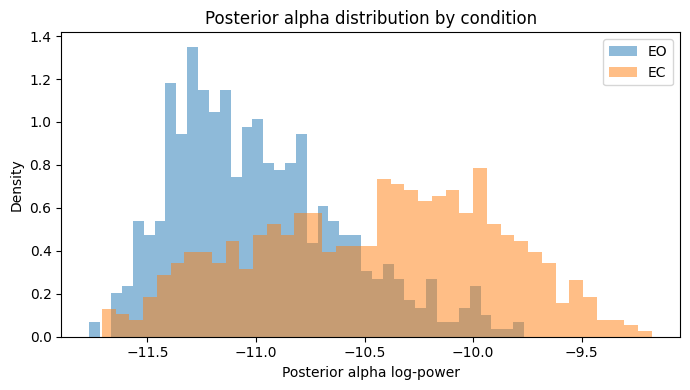

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
EC,601.0,-10.456311,0.559290,-11.710380,-10.894647,-10.392734,-10.024582,-9.176282
EO,592.0,-10.988558,0.391325,-11.767508,-11.287506,-11.040129,-10.765306,-9.765484


In [4]:
plt.figure(figsize=(7, 4))

for condition in ["EO", "EC"]:
    vals = analysis_df.loc[
        analysis_df["condition"] == condition,
        "posterior_alpha_log"
    ].dropna()

    plt.hist(vals, bins=40, alpha=0.5, label=condition, density=True)

plt.xlabel("Posterior alpha log-power")
plt.ylabel("Density")
plt.title("Posterior alpha distribution by condition")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "subject_independent_posterior_alpha_distribution.png", dpi=300)
plt.show()

display(
    analysis_df
    .groupby("condition")["posterior_alpha_log"]
    .describe()
)


## 4. Helper functions for grouped cross-validation

In [5]:
def participant_bootstrap_accuracy_ci(predictions, n_boot=5000, seed=42):
    """Bootstrap a 95% CI for accuracy by resampling participants.

    This respects the fact that each participant can contribute two recordings.
    """
    rng = np.random.default_rng(seed)

    participant_ids = predictions["participant_id"].drop_duplicates().values
    participant_to_rows = {
        pid: predictions.index[predictions["participant_id"] == pid].to_numpy()
        for pid in participant_ids
    }

    boot = []

    for _ in range(n_boot):
        sampled_pids = rng.choice(participant_ids, size=len(participant_ids), replace=True)
        sampled_indices = np.concatenate([participant_to_rows[pid] for pid in sampled_pids])
        sampled = predictions.loc[sampled_indices]
        boot.append((sampled["y_true"] == sampled["y_pred"]).mean())

    return np.percentile(boot, [2.5, 97.5])


def make_group_folds(df, n_splits=5):
    """Create participant-grouped CV folds."""
    groups = df["participant_id"].values
    y = df["y"].values

    # GroupKFold is enough here because each included participant normally has both EO and EC.
    # Therefore, each participant group is internally balanced.
    cv = GroupKFold(n_splits=n_splits)

    return list(cv.split(df, y, groups=groups))


def run_subject_independent_logistic_cv(df, feature_cols, model_name, penalty="l2", C=1.0, n_splits=5):
    """Run participant-grouped CV logistic regression."""
    d = df.copy()

    # Keep features that exist and are not entirely missing.
    valid_cols = [
        col for col in feature_cols
        if col in d.columns and not d[col].isna().all()
    ]

    if len(valid_cols) == 0:
        raise ValueError(f"No valid features for {model_name}.")

    X = d[valid_cols].copy()
    y = d["y"].astype(int).copy()

    solver = "liblinear" if penalty == "l1" else "lbfgs"

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            max_iter=5000,
            random_state=42,
        )),
    ])

    folds = make_group_folds(d, n_splits=n_splits)

    pred_rows = []
    coef_rows = []

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        test_rows = d.iloc[test_idx]

        for row_i, true, pred, proba in zip(test_rows.index, y_test, y_pred, y_proba):
            row = d.loc[row_i]
            pred_rows.append({
                "recording_id": row["recording_id"],
                "participant_id": row["participant_id"],
                "condition": row["condition"],
                "setting": "subject_independent",
                "model_name": model_name,
                "fold": fold,
                "y_true": int(true),
                "y_pred": int(pred),
                "y_proba": float(proba),
                "correct": bool(true == pred),
            })

        logreg = model.named_steps["logreg"]
        coefs = logreg.coef_[0]

        for feature, coef in zip(valid_cols, coefs):
            coef_rows.append({
                "setting": "subject_independent",
                "model_name": model_name,
                "fold": fold,
                "feature": feature,
                "coefficient": coef,
            })

    predictions = pd.DataFrame(pred_rows)
    coefficients = pd.DataFrame(coef_rows)

    acc = accuracy_score(predictions["y_true"], predictions["y_pred"])
    bal_acc = balanced_accuracy_score(predictions["y_true"], predictions["y_pred"])

    try:
        auc = roc_auc_score(predictions["y_true"], predictions["y_proba"])
    except ValueError:
        auc = np.nan

    ci_low, ci_high = participant_bootstrap_accuracy_ci(predictions)

    result = {
        "setting": "subject_independent",
        "model_name": model_name,
        "feature_set": ", ".join(valid_cols),
        "n_recordings": len(predictions),
        "n_participants": predictions["participant_id"].nunique(),
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "roc_auc": auc,
        "ci_lower": ci_low,
        "ci_upper": ci_high,
        "notes": (
            "Logistic regression with participant-grouped cross-validation. "
            f"Penalty={penalty}, C={C}."
        ),
    }

    return result, predictions, coefficients


## 5. Define feature sets

The key comparison is between a simple one-feature classifier and increasingly complex feature sets.

The subject-independent models are trained models, so they use cross-validation.


In [6]:
posterior_channel_alpha_features = [
    col for col in analysis_df.columns
    if col.startswith("ch_") and col.endswith("_alpha_log")
]

welch_multiband_features = [
    "posterior_delta_log",
    "posterior_theta_log",
    "posterior_alpha_log",
    "posterior_beta_log",
    "posterior_high_beta_log",
    "posterior_alpha_rel",
]

welch_multiband_features = [
    col for col in welch_multiband_features
    if col in analysis_df.columns
]

fooof_features = [
    "fooof_alpha_cf",
    "fooof_alpha_peak_power",
    "fooof_alpha_bandwidth",
    "fooof_aperiodic_exponent",
]

fooof_features = [
    col for col in fooof_features
    if col in analysis_df.columns
]

combined_features = list(dict.fromkeys(
    posterior_channel_alpha_features
    + welch_multiband_features
    + fooof_features
))

feature_sets = {
    "subject_lr_oz_alpha_L2": ["oz_alpha_log"],
    "subject_lr_occipital_alpha_L2": ["occipital_alpha_log"],
    "subject_lr_posterior_alpha_L2": ["posterior_alpha_log"],
    "subject_lr_posterior_channels_L2": posterior_channel_alpha_features,
    "subject_lr_welch_multiband_L2": welch_multiband_features,
}

if len(fooof_features) > 0:
    feature_sets["subject_lr_fooof_L2"] = fooof_features
    feature_sets["subject_lr_combined_L2"] = combined_features

print("N posterior channel alpha features:", len(posterior_channel_alpha_features))
print("Welch multiband features:", welch_multiband_features)
print("FOOOF features:", fooof_features)
print("N combined features:", len(combined_features))


N posterior channel alpha features: 19
Welch multiband features: ['posterior_delta_log', 'posterior_theta_log', 'posterior_alpha_log', 'posterior_beta_log', 'posterior_high_beta_log', 'posterior_alpha_rel']
FOOOF features: ['fooof_alpha_cf', 'fooof_alpha_peak_power', 'fooof_alpha_bandwidth', 'fooof_aperiodic_exponent']
N combined features: 29


## 6. Run subject-independent logistic-regression models

In [7]:
all_results = []
all_predictions = []
all_coefficients = []

for model_name, feature_cols in feature_sets.items():
    result, pred, coef = run_subject_independent_logistic_cv(
        analysis_df,
        feature_cols,
        model_name=model_name,
        penalty="l2",
        C=1.0,
        n_splits=5,
    )

    all_results.append(result)
    all_predictions.append(pred)
    all_coefficients.append(coef)

subject_results = pd.DataFrame(all_results)
subject_predictions = pd.concat(all_predictions, ignore_index=True)
subject_coefficients = pd.concat(all_coefficients, ignore_index=True)

display(subject_results[[
    "model_name",
    "n_recordings",
    "n_participants",
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "ci_lower",
    "ci_upper",
]])


,model_name,n_recordings,n_participants,accuracy,balanced_accuracy,roc_auc,ci_lower,ci_upper
0,subject_lr_oz_alpha_L2,1193,602,0.717519,0.717775,0.771302,0.697651,0.737637
1,subject_lr_occipital_alpha_L2,1193,602,0.725901,0.726208,0.780920,0.706030,0.746032
2,subject_lr_posterior_alpha_L2,1193,602,0.709975,0.710287,0.772058,0.689596,0.729935
3,subject_lr_posterior_channels_L2,1193,602,0.787930,0.788379,0.844333,0.768395,0.808368
4,subject_lr_welch_multiband_L2,1193,602,0.812238,0.812329,0.891782,0.792121,0.832633
5,subject_lr_fooof_L2,1193,602,0.772003,0.772180,0.856885,0.749791,0.793132
6,subject_lr_combined_L2,1193,602,0.845767,0.845948,0.922131,0.826194,0.865435


## 7. Optional L1-regularized models

L1 regularization gives a simple feature-selection check. It can show whether multifeature models mainly retain alpha-related features.


In [8]:
RUN_L1_MODELS = True

if RUN_L1_MODELS:
    l1_feature_sets = {
        "subject_lr_posterior_channels_L1": posterior_channel_alpha_features,
        "subject_lr_welch_multiband_L1": welch_multiband_features,
    }

    if len(fooof_features) > 0:
        l1_feature_sets["subject_lr_combined_L1"] = combined_features

    for model_name, feature_cols in l1_feature_sets.items():
        result, pred, coef = run_subject_independent_logistic_cv(
            analysis_df,
            feature_cols,
            model_name=model_name,
            penalty="l1",
            C=1.0,
            n_splits=5,
        )

        all_results.append(result)
        all_predictions.append(pred)
        all_coefficients.append(coef)

    subject_results = pd.DataFrame(all_results)
    subject_predictions = pd.concat(all_predictions, ignore_index=True)
    subject_coefficients = pd.concat(all_coefficients, ignore_index=True)

display(subject_results[[
    "model_name",
    "n_recordings",
    "n_participants",
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "ci_lower",
    "ci_upper",
]])


,model_name,n_recordings,n_participants,accuracy,balanced_accuracy,roc_auc,ci_lower,ci_upper
0,subject_lr_oz_alpha_L2,1193,602,0.717519,0.717775,0.771302,0.697651,0.737637
1,subject_lr_occipital_alpha_L2,1193,602,0.725901,0.726208,0.780920,0.706030,0.746032
2,subject_lr_posterior_alpha_L2,1193,602,0.709975,0.710287,0.772058,0.689596,0.729935
3,subject_lr_posterior_channels_L2,1193,602,0.787930,0.788379,0.844333,0.768395,0.808368
4,subject_lr_welch_multiband_L2,1193,602,0.812238,0.812329,0.891782,0.792121,0.832633
5,subject_lr_fooof_L2,1193,602,0.772003,0.772180,0.856885,0.749791,0.793132
6,subject_lr_combined_L2,1193,602,0.845767,0.845948,0.922131,0.826194,0.865435
7,subject_lr_posterior_channels_L1,1193,602,0.792959,0.793409,0.845682,0.773296,0.813760
8,subject_lr_welch_multiband_L1,1193,602,0.811400,0.811484,0.891869,0.790929,0.831658
9,subject_lr_combined_L1,1193,602,0.853311,0.853499,0.923571,0.834454,0.872590


## 8. Confusion matrices

These show what kinds of mistakes each model makes.

Rows are the true condition and columns are the predicted condition.


In [9]:
for model_name in subject_results["model_name"]:
    pred = subject_predictions[subject_predictions["model_name"] == model_name]

    cm = confusion_matrix(pred["y_true"], pred["y_pred"], labels=[0, 1])
    cm_df = pd.DataFrame(
        cm,
        index=["true_EO", "true_EC"],
        columns=["pred_EO", "pred_EC"],
    )

    print("\n", model_name)
    display(cm_df)



 subject_lr_oz_alpha_L2


,pred_EO,pred_EC
true_EO,445,147
true_EC,190,411



 subject_lr_occipital_alpha_L2


,pred_EO,pred_EC
true_EO,454,138
true_EC,189,412



 subject_lr_posterior_alpha_L2


...

,pred_EO,pred_EC
true_EO,505,87
true_EC,160,441



 subject_lr_welch_multiband_L1


,pred_EO,pred_EC
true_EO,487,105
true_EC,120,481



 subject_lr_combined_L1


,pred_EO,pred_EC
true_EO,520,72
true_EC,103,498


## 9. Save subject-independent results

In [10]:
subject_results.to_csv(SUBJECT_RESULTS_FILE, index=False)
subject_predictions.to_csv(SUBJECT_PREDICTIONS_FILE, index=False)
subject_coefficients.to_csv(SUBJECT_COEFFICIENTS_FILE, index=False)

print("Saved:", SUBJECT_RESULTS_FILE)
print("Saved:", SUBJECT_PREDICTIONS_FILE)
print("Saved:", SUBJECT_COEFFICIENTS_FILE)


Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\model_results\subject_independent_results.csv
Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\model_results\subject_independent_predictions.csv
Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\model_results\subject_independent_coefficients.csv


## 10. Figure: subject-independent model performance

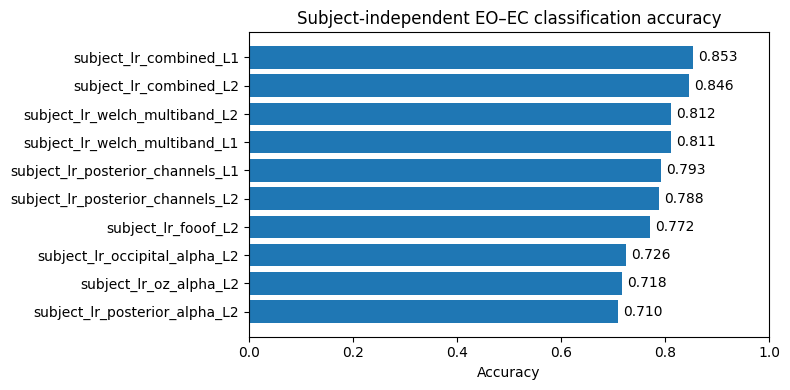

In [11]:
plot_results = subject_results.copy()
plot_results = plot_results.sort_values("accuracy", ascending=True)

plt.figure(figsize=(8, max(4, 0.35 * len(plot_results))))
plt.barh(plot_results["model_name"], plot_results["accuracy"])
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Subject-independent EO–EC classification accuracy")

for i, (_, row) in enumerate(plot_results.iterrows()):
    plt.text(
        row["accuracy"] + 0.01,
        i,
        f"{row['accuracy']:.3f}",
        va="center",
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "subject_independent_model_accuracy.png", dpi=300)
plt.show()


## 11. Compare paired and subject-independent results

This comparison is the key report point:

- Paired models compare EO and EC within the same participant.
- Subject-independent models classify each recording separately for unseen participants.

If paired performance is much higher, this shows that paired data provides a large advantage.


,setting,model_name,accuracy,roc_auc
5,paired,paired_lr_welch_multiband_L2,0.974619,0.996370
9,paired,paired_lr_welch_multiband_L1,0.974619,0.996839
10,paired,paired_lr_combined_L1,0.969543,0.996519
7,paired,paired_lr_combined_L2,0.967851,0.996622
6,paired,paired_lr_fooof_L2,0.945854,0.989017
1,paired,simple_rule_occipital_alpha,0.944162,NaN
3,paired,paired_lr_posterior_alpha_L2,0.942470,0.988284
4,paired,paired_lr_posterior_channels_L2,0.942470,0.989682
8,paired,paired_lr_posterior_channels_L1,0.939086,0.989670
2,paired,simple_rule_posterior_alpha,0.937394,NaN


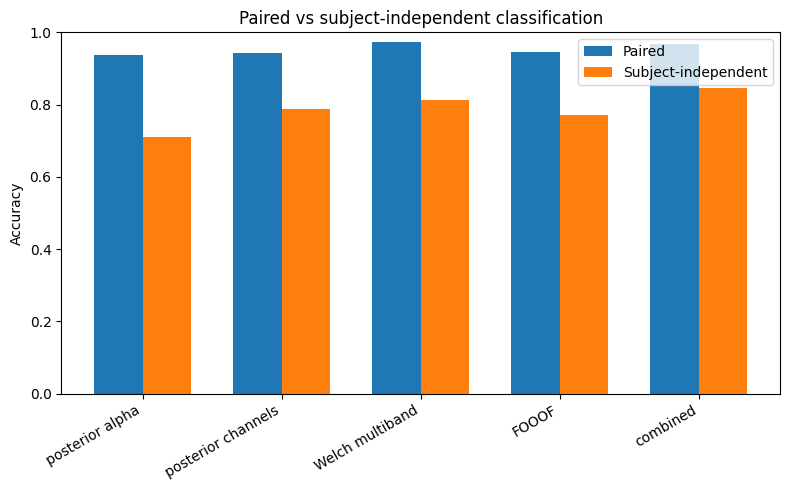

In [12]:
if PAIRED_RESULTS_FILE.exists():
    paired_results = pd.read_csv(PAIRED_RESULTS_FILE)

    paired_plot = paired_results[[
        "setting",
        "model_name",
        "accuracy",
        "roc_auc",
    ]].copy()

    subject_plot = subject_results[[
        "setting",
        "model_name",
        "accuracy",
        "roc_auc",
    ]].copy()

    comparison = pd.concat([paired_plot, subject_plot], ignore_index=True)

    display(comparison.sort_values(["setting", "accuracy"], ascending=[True, False]))

    # Compact comparison of most similar models.
    mapping = {
        "simple_rule_posterior_alpha": "posterior alpha",
        "paired_lr_posterior_alpha_L2": "posterior alpha",
        "subject_lr_posterior_alpha_L2": "posterior alpha",
        "paired_lr_posterior_channels_L2": "posterior channels",
        "subject_lr_posterior_channels_L2": "posterior channels",
        "paired_lr_welch_multiband_L2": "Welch multiband",
        "subject_lr_welch_multiband_L2": "Welch multiband",
        "paired_lr_fooof_L2": "FOOOF",
        "subject_lr_fooof_L2": "FOOOF",
        "paired_lr_combined_L2": "combined",
        "subject_lr_combined_L2": "combined",
    }

    comparison["model_family"] = comparison["model_name"].map(mapping)

    compact = comparison.dropna(subset=["model_family"]).copy()

    plt.figure(figsize=(8, 5))

    families = ["posterior alpha", "posterior channels", "Welch multiband", "FOOOF", "combined"]
    x = np.arange(len(families))
    width = 0.35

    paired_acc = []
    subject_acc = []

    for fam in families:
        p = compact[
            (compact["setting"] == "paired")
            & (compact["model_family"] == fam)
            & (~compact["model_name"].str.contains("L1", na=False))
        ]["accuracy"]

        s = compact[
            (compact["setting"] == "subject_independent")
            & (compact["model_family"] == fam)
            & (~compact["model_name"].str.contains("L1", na=False))
        ]["accuracy"]

        paired_acc.append(p.iloc[0] if len(p) else np.nan)
        subject_acc.append(s.iloc[0] if len(s) else np.nan)

    plt.bar(x - width/2, paired_acc, width, label="Paired")
    plt.bar(x + width/2, subject_acc, width, label="Subject-independent")

    plt.xticks(x, families, rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title("Paired vs subject-independent classification")
    plt.legend()
    plt.tight_layout()

    plt.savefig(FIGURES_DIR / "paired_vs_subject_independent_accuracy.png", dpi=300)
    plt.show()

else:
    print("Paired results file not found. Run 03a first to make the comparison figure.")


## 12. Coefficient summaries

These help interpret what the complex models learned.


,model_name,feature,mean_coefficient,sd_coefficient
2,subject_lr_combined_L1,ch_Oz_alpha_log,-3.022070,0.400971
9,subject_lr_combined_L1,ch_P7_alpha_log,-1.584064,0.275798
5,subject_lr_combined_L1,ch_P3_alpha_log,-1.538964,0.801234
26,subject_lr_combined_L1,posterior_delta_log,-1.032683,0.098520
10,subject_lr_combined_L1,ch_P8_alpha_log,-1.016800,0.242956
...,...,...,...,...
114,subject_lr_welch_multiband_L2,posterior_theta_log,-0.220284,0.054047
113,subject_lr_welch_multiband_L2,posterior_high_beta_log,-0.111776,0.041803
111,subject_lr_welch_multiband_L2,posterior_beta_log,0.324189,0.101370
110,subject_lr_welch_multiband_L2,posterior_alpha_rel,0.742200,0.174328


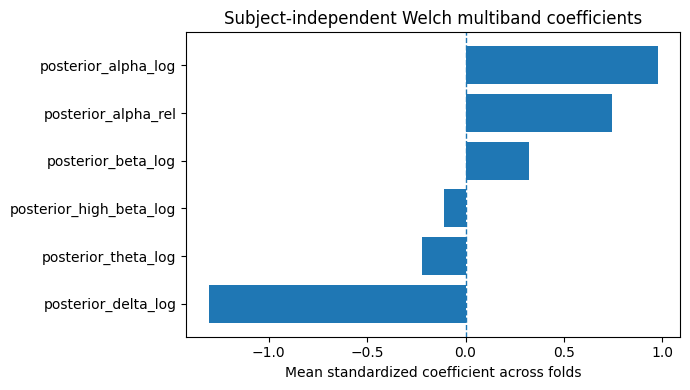

In [13]:
coef_summary = (
    subject_coefficients
    .groupby(["model_name", "feature"])
    .agg(
        mean_coefficient=("coefficient", "mean"),
        sd_coefficient=("coefficient", "std"),
    )
    .reset_index()
)

display(coef_summary.sort_values(["model_name", "mean_coefficient"]))

selected_model = "subject_lr_welch_multiband_L2"

if selected_model in coef_summary["model_name"].unique():
    selected = (
        coef_summary
        .query("model_name == @selected_model")
        .sort_values("mean_coefficient")
    )

    plt.figure(figsize=(7, max(4, 0.35 * len(selected))))
    plt.barh(selected["feature"], selected["mean_coefficient"])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Mean standardized coefficient across folds")
    plt.title("Subject-independent Welch multiband coefficients")
    plt.tight_layout()

    plt.savefig(FIGURES_DIR / "subject_independent_welch_coefficients.png", dpi=300)
    plt.show()
